In [2]:
import pandas as pd

In [4]:
olist_df = pd.read_csv(
    "../01_data/preprocessed/olist_order_item_baseline.csv"
)

olist_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  str    
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  str    
 3   seller_id                      112650 non-null  str    
 4   shipping_limit_date            112650 non-null  str    
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   customer_id                    112650 non-null  str    
 8   order_status                   112650 non-null  str    
 9   order_purchase_timestamp       112650 non-null  str    
 10  order_approved_at              112635 non-null  str    
 11  order_delivered_carrier_date   111456 non-null  str    
 12  order_delivered_customer_date  110196 non

# Exploratory Data Analysis

This analysis explores marketplace activity, customer behavior, seller
performance, and order fulfillment to identify business opportunities
that may support an actionable predictive application.

In [5]:
print("Orders:", olist_df["order_id"].nunique())
print("Customers:", olist_df["customer_unique_id"].nunique())
print("Sellers:", olist_df["seller_id"].nunique())
print("Products:", olist_df["product_id"].nunique())

Orders: 98666
Customers: 95420
Sellers: 3095
Products: 32951


In [6]:
olist_df["order_purchase_timestamp"] = pd.to_datetime(
    olist_df["order_purchase_timestamp"]
)

print(
    "Purchase date range:",
    olist_df["order_purchase_timestamp"].min(),
    "to",
    olist_df["order_purchase_timestamp"].max(),
)

Purchase date range: 2016-09-04 21:15:19 to 2018-09-03 09:06:57


order_purchase_timestamp
2016-09-01       3
2016-10-01     308
2016-11-01       0
2016-12-01       1
2017-01-01     789
2017-02-01    1733
2017-03-01    2641
2017-04-01    2391
2017-05-01    3660
2017-06-01    3217
2017-07-01    3969
2017-08-01    4293
2017-09-01    4243
2017-10-01    4568
2017-11-01    7451
2017-12-01    5624
2018-01-01    7220
2018-02-01    6694
2018-03-01    7188
2018-04-01    6934
2018-05-01    6853
2018-06-01    6160
2018-07-01    6273
2018-08-01    6452
2018-09-01       1
Freq: MS, dtype: int64

<Axes: title={'center': 'Monthly Orders'}, xlabel='Month', ylabel='Orders'>

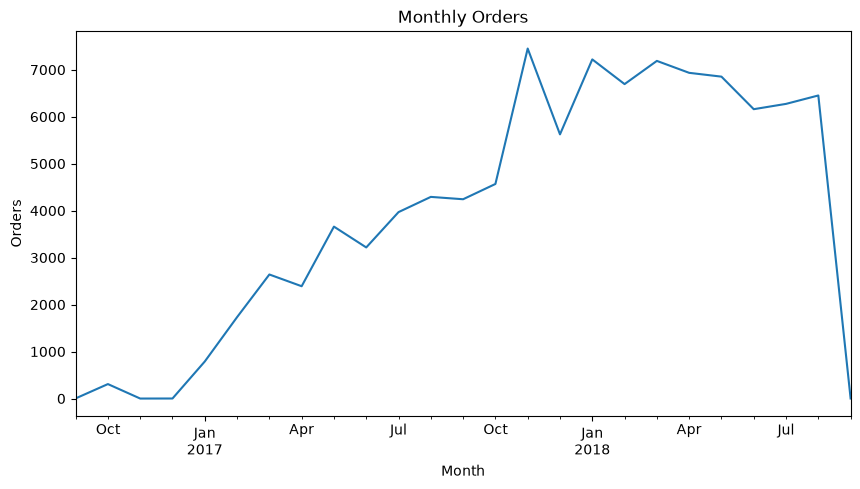

In [9]:
monthly_orders = (
    olist_df[["order_id", "order_purchase_timestamp"]]
    .drop_duplicates("order_id")
    .set_index("order_purchase_timestamp")
    .resample("MS")
    .size()
)

display(monthly_orders)

monthly_orders.plot(
    figsize=(10, 5),
    title="Monthly Orders",
    xlabel="Month",
    ylabel="Orders",
)

In [13]:
customer_orders = (
    olist_df[["customer_unique_id", "order_id"]]
    .drop_duplicates()
    .groupby("customer_unique_id")
    .size()
)

display(customer_orders.value_counts().sort_index())

repeat_customer_rate = (customer_orders > 1).mean()

print(f"Repeat customer rate: {repeat_customer_rate:.2%}")

1     92507
2      2673
3       192
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64

Repeat customer rate: 3.05%


In [24]:
order_value = (
    olist_df[
        ["order_id", "payment_value"]
    ]
    .drop_duplicates("order_id")
)

order_value["payment_value"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count    98665.000000
mean       160.606904
std        220.484252
min          9.590000
50%        105.290000
75%        176.880000
90%        307.714000
95%        450.530000
99%       1063.327600
max      13664.080000
Name: payment_value, dtype: float64

In [26]:
total_value = order_value["payment_value"].sum()

for pct in [0.01, 0.05, 0.10]:
    n = int(len(order_value) * pct)
    top_value = order_value.nlargest(n, "payment_value")["payment_value"].sum()

    print(
        f"Top {pct:.0%} of orders: "
        f"{top_value / total_value:.1%} of total value"
    )

Top 1% of orders: 10.4% of total value
Top 5% of orders: 26.8% of total value
Top 10% of orders: 38.2% of total value


In [27]:
shipping = olist_df[
    ["price", "freight_value"]
].copy()

shipping["freight_pct"] = (
    shipping["freight_value"] / shipping["price"]
)

shipping[
    ["price", "freight_value", "freight_pct"]
].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

,price,freight_value,freight_pct
count,112650.000000,112650.000000,112650.000000
mean,120.653739,19.990320,0.320864
std,183.633928,15.806405,0.349894
min,0.850000,0.000000,0.000000
50%,74.990000,16.260000,0.231356
75%,134.900000,21.150000,0.393036
90%,229.800000,34.041000,0.642857
95%,349.900000,45.120000,0.874702
99%,890.000000,84.520000,1.549451
max,6735.000000,409.680000,26.235294


In [28]:
shipping_dates = olist_df[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]
].drop_duplicates("order_id").copy()

date_cols = shipping_dates.columns[1:]

shipping_dates[date_cols] = shipping_dates[
    date_cols
].apply(pd.to_datetime)

shipping_dates["delivery_days"] = (
    shipping_dates["order_delivered_customer_date"]
    - shipping_dates["order_purchase_timestamp"]
).dt.total_seconds() / 86400

shipping_dates["delivery_vs_estimate_days"] = (
    shipping_dates["order_delivered_customer_date"]
    - shipping_dates["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

shipping_dates[
    ["delivery_days", "delivery_vs_estimate_days"]
].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

,delivery_days,delivery_vs_estimate_days
count,96476.000000,96476.000000
mean,12.558702,-11.179120
std,9.546530,10.186113
min,0.533414,-146.016123
50%,10.217755,-11.948941
75%,15.720327,-6.390000
90%,23.097604,-1.137517
95%,29.276016,3.818458
99%,46.049913,18.939306
max,209.628611,188.975081
